# Data Collection and Preparation

The provided dataset is a historical dataset of taxi data from Chicago, USA. The data was made available by the Chicago Data Portal and contains taxi trips from 2024 onwards.

## 1. Imports & Setup

In [19]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plotting defaults
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

print("All core imports successful.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")


All core imports successful.
pandas  : 3.0.2
numpy   : 2.4.4


In [20]:
# import dataset
df = pd.read_csv("Taxi_Trips_(2024-).csv")

In [21]:
df["Trip Start Timestamp"] = pd.to_datetime(df["Trip Start Timestamp"])
df["Trip End Timestamp"] = pd.to_datetime(df["Trip End Timestamp"])

## 2. Initial Inspection

In [22]:
df.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,c107c04a1b74fa964072ae605bca82d9aa76d2eb,38d00610debf2306201a33902c298ea78df627880d3d19...,2026-05-01,2026-05-01 00:00:00,399,1.38,NaN,NaN,8.0,8.0,...,$0.00,$6.75,Cash,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,83defb6f253341e24be3c2d010c6e253ba38ca47,03906d62f91d139ab93f74f50d1b208805b7fbb61e8d1e...,2026-05-01,2026-05-01 00:15:00,"1,083",9.93,NaN,NaN,76.0,NaN,...,$5.00,$31.25,Cash,5 Star Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),NaN,NaN,NaN
2,08ef88dc90712c9d7cfcb5d1edac9d6fb070d9db,38f6145c9a2b848dc1baa16fd91087e606b12bcb8757a9...,2026-05-01,2026-05-01 00:15:00,"1,260",4.7,NaN,NaN,8.0,23.0,...,$0.00,$16.00,Cash,Transit Administrative Center Inc,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.900070,-87.720918,POINT (-87.7209182385 41.9000696026)
3,863b9b2b00af33990eb59400b6db1ac586d58a16,f9bc93a0ba6b1f18c9709a96c99bb9c5a99054b1711f80...,2026-05-01,2026-05-01 00:00:00,648,3.55,NaN,NaN,76.0,NaN,...,$4.00,$16.50,Credit Card,City Service,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),NaN,NaN,NaN
4,9360cffa2936c678348fa228fc5ba0570767b25b,48c0b5669ed50a0dcd8bf0e69fd99bb2669cb027ec06c0...,2026-05-01,2026-05-01 00:00:00,698,3.82,NaN,NaN,28.0,8.0,...,$0.00,$30.60,Credit Card,Flash Cab,41.874005,-87.663518,POINT (-87.6635175498 41.874005383),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15406960 entries, 0 to 15406959
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Trip ID                     str           
 1   Taxi ID                     str           
 2   Trip Start Timestamp        datetime64[us]
 3   Trip End Timestamp          datetime64[us]
 4   Trip Seconds                str           
 5   Trip Miles                  object        
 6   Pickup Census Tract         float64       
 7   Dropoff Census Tract        float64       
 8   Pickup Community Area       float64       
 9   Dropoff Community Area      float64       
 10  Fare                        str           
 11  Tips                        str           
 12  Tolls                       str           
 13  Extras                      str           
 14  Trip Total                  str           
 15  Payment Type                str           
 16  Company                    

## 3. Missing Value Analysis

Spatial columns (census tract, community area) are intentionally suppressed for privacy when trips start/end outside Chicago proper.

In [24]:
missing = (df.isnull().sum()
           .rename("n_missing")
           .to_frame()
           .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(df))
           .sort_values("pct_missing", ascending=False))

display(missing.style.background_gradient(cmap="OrRd", subset=["pct_missing"]))


,n_missing,pct_missing
Dropoff Census Tract,8751654,56.803250
Pickup Census Tract,8547337,55.477116
Dropoff Community Area,1366538,8.869615
Dropoff Centroid Longitude,1285413,8.343067
Dropoff Centroid Location,1285413,8.343067
Dropoff Centroid Latitude,1285413,8.343067
Pickup Community Area,429216,2.785858
Pickup Centroid Location,421354,2.734829
Pickup Centroid Latitude,421354,2.734829
Pickup Centroid Longitude,421354,2.734829


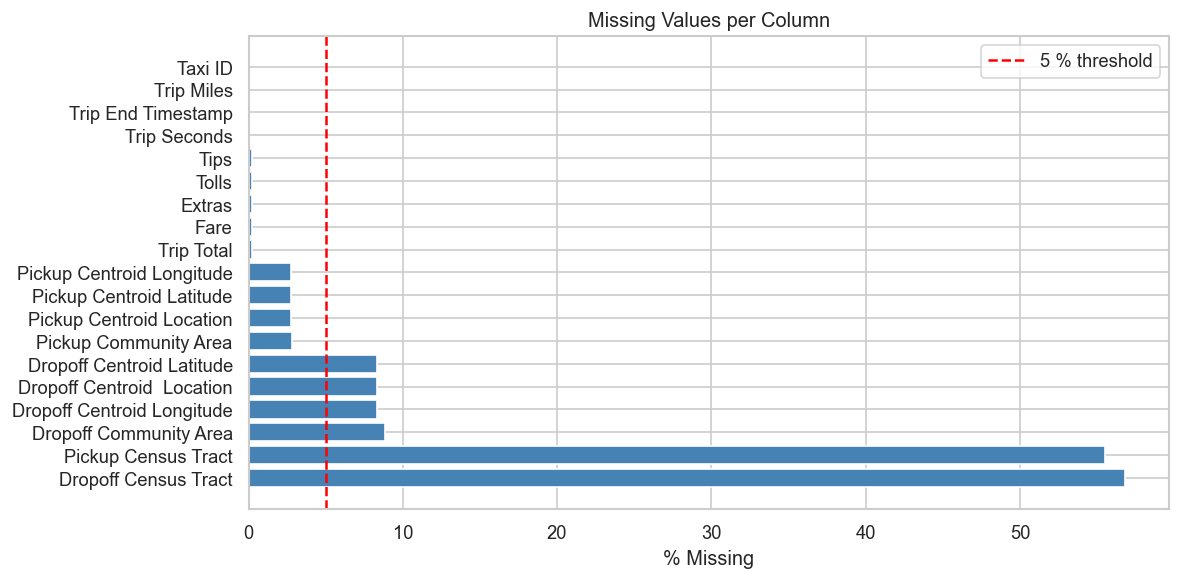

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_plot = missing[missing["pct_missing"] > 0]
ax.barh(missing_plot.index, missing_plot["pct_missing"], color="steelblue")
ax.set_xlabel("% Missing")
ax.set_title("Missing Values per Column")
ax.axvline(5, color="red", linestyle="--", label="5 % threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Data Cleaning

### 4.1 Sensitivising Data

In [26]:
df["Trip Miles"] = df["Trip Miles"].str.replace(".", "", regex=False)
df["Trip Miles"] = df["Trip Miles"].str.replace(",", ".", regex=False)
df["Trip Miles"] = pd.to_numeric(df["Trip Miles"])

In [27]:
df["Trip Seconds"] = df["Trip Seconds"].str.replace(".", "", regex=False)
df["Trip Seconds"] = df["Trip Seconds"].str.replace(",", ".", regex=False)
df["Trip Seconds"] = pd.to_numeric(df["Trip Seconds"])

In [28]:
df["Extras"] = df["Extras"].str.replace(",", ".", regex=False)
df["Extras"] = df["Extras"].str.replace("$", "", regex=False)
df["Tips"] = df["Tips"].str.replace(",", ".", regex=False)
df["Tips"] = df["Tips"].str.replace("$", "", regex=False)
df["Tolls"] = df["Tolls"].str.replace(",", ".", regex=False)
df["Tolls"] = df["Tolls"].str.replace("$", "", regex=False)
df["Fare"] = df["Fare"].str.replace(",", ".", regex=False)
df["Fare"] = df["Fare"].str.replace("$", "", regex=False)

### 4.2 Drop duplicates

In [29]:
n_before = len(df)
# drop duplicates in Trip ID
df = df.drop_duplicates(subset="Trip ID")
print(f"Dropped {n_before - len(df):,} duplicate rows")

Dropped 0 duplicate rows


### 4.3 Remove implausible trips

In [30]:
df.columns

Index(['Trip ID', 'Taxi ID', 'Trip Start Timestamp', 'Trip End Timestamp',
       'Trip Seconds', 'Trip Miles', 'Pickup Census Tract',
       'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tips', 'Tolls', 'Extras',
       'Trip Total', 'Payment Type', 'Company', 'Pickup Centroid Latitude',
       'Pickup Centroid Longitude', 'Pickup Centroid Location',
       'Dropoff Centroid Latitude', 'Dropoff Centroid Longitude',
       'Dropoff Centroid  Location'],
      dtype='str')

In [ ]:
n_before = len(df)
df = df[df["Trip Seconds"] >= 60]  # trip longer than 1 minute
df = df[df["Trip Total"] != 0] # free trips don't count

print(f"Removed {n_before - len(df):,} implausible/incomplete rows")
print(f"Remaining: {len(df):,} rows")

Removed 0 implausible/incomplete rows
Remaining: 7,532,843 rows


In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 7532843 entries, 0 to 15406959
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Trip ID                     str           
 1   Taxi ID                     str           
 2   Trip Start Timestamp        datetime64[us]
 3   Trip End Timestamp          datetime64[us]
 4   Trip Seconds                float64       
 5   Trip Miles                  float64       
 6   Pickup Census Tract         float64       
 7   Dropoff Census Tract        float64       
 8   Pickup Community Area       float64       
 9   Dropoff Community Area      float64       
 10  Fare                        str           
 11  Tips                        str           
 12  Tolls                       str           
 13  Extras                      str           
 14  Trip Total                  str           
 15  Payment Type                str           
 16  Company                     str  